<font color="blue">**This notebook is used to train an MLP on filter frequency response data to realize a synthesis tool for an arbitrary piecewise-continuous frequency response.**

1.   <font color="blue">It requires installation of PySPice library for analysis of a filter.

2. <font color="blue">Number of samples in frequency response is 129.

3. <font color="blue">Filter passband is from 2300MHz to 2400MHz.

4. <font color="blue">Filter frequency response is collected from 1800MHz to 2800MHz.

5. <font color="blue">Inductor values are uH ( micro-Henry) and capacitor values are in pF ( pico-Farad)

6. <font color="blue"> Trained MLP is saved and used to make prediction  for filter compnents when inputs is a piecewise continouous frequency reponse.  MLP design comapred to one derived using an optimization routine.

7. <font color="blue"> Hyperparamter search was done using Optuna library


<font color="blue">**Step 1:** First install PySpice and check that it is working corretly.

In [1]:
# First installed conda for PySpice installtion
# This could take up to 30 sec
!pip install condacolab
import condacolab
condacolab.install()
# NOTE: Colab will restart the kernel here. Run the next cell after it restarts.

✨🍰✨ Everything looks OK!


In [ ]:
# Install ngspice packages, including executables & master package
# This could take 2-3 minutes
!conda install -c conda-forge ngspice-exe --quiet
!conda install -c conda-forge ngspice --quiet
!conda install -c conda-forge ngspice-lib --quiet

# Install pyspice using pip
!pip install -q pyspice

# This is optional: run this to ensure PySpice is installed
!pyspice-post-installation --check-install

# Install optuna if not present
!pip install -q optuna


<font color="blue">**Step 2:** Import all necessary libraries

In [3]:
#Import all needed libraries
#!/usr/bin/env python3

import sys
import os
import subprocess
import re
import copy
import random
import joblib
from collections import namedtuple
import numpy as np
from numpy._core.numerictypes import int32
import pandas as pd
import matplotlib.pyplot as plt
import time
from scipy.optimize import minimize

# Automatically install optuna if not found in current environment
try:
    import optuna
except ImportError:
    print("optuna not found. Installing in the current environment...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "optuna"])
    import optuna

import optuna.visualization as vis
import plotly.io as pio
# Set default renderer for Colab to display interactive plots
pio.renderers.default = 'colab'

from sklearn.model_selection import train_test_split
from sklearn.preprocessing   import StandardScaler

# Automatically install tensorboardX if not found
try:
    import tensorboardX
except ImportError:
    print("tensorboardX not found. Installing in the current environment...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "tensorboardX"])
from tensorboardX import SummaryWriter
import torch
import torch.nn as nn
import torch.optim as optim
from   torch.utils.data import DataLoader, TensorDataset

# Fix: PySpice was installed in python3.11 site-packages, add it to path if not present
if "/usr/local/lib/python3.11/site-packages" not in sys.path:
    sys.path.append("/usr/local/lib/python3.11/site-packages")
from PySpice.Spice.Netlist import Circuit
from PySpice.Unit import *
from PySpice.Spice.NgSpice import Shared as NgSpiceShared
from PySpice.Spice.NgSpice.Shared import ffi


<font color="blue"> **Step 3:** Set config parameters and define methods for filter synthesis and frequency response analysis.

In [4]:
####### CONFIG PARAMETERS #########
# lowest value of frequency response
val_FR_lo=-65
# highest value of frequency response
val_FR_hi=5
# lowest frequency for plot
val_Freq_lo = 1800
# highest frequency for plot
val_Freq_hi = 2800
# number of points in frequency response of network
N_FreqResp=129
FreqVec_MHz=np.linspace(1800,2800,N_FreqResp)

# Calculate indices for the passband (2300 - 2400 MHz)
passband_indices = np.where((FreqVec_MHz >= 2300) & (FreqVec_MHz <= 2400))[0]

# in band max allowed in-band loss
max_inband_loss=-3

# for supervised learning
in_band_weight_SL = 100.0
in_band_weight_Opt = 100.0

#-------------------------------------------------------------------------------
# Define method to AC simulate the synthesized network
# It only works for third order filters currenlty
def ACsim(L_nH,Cs_fF,Cp_fF,freqs_MHz, render_mode):
  # scale components
  L_uH =L_nH /1E3
  Cs_pF=Cs_fF/1E3
  Cp_pF=Cp_fF/1E3

  # 1. Define the Circuit
  circuit = Circuit('SynthNet')
  #print(L_uH, Cs_pF, Cp_PF)
  # AC voltage source: Define directly with SPICE string to ensure AC parameter is included
  # Syntax: V<name> <node+> <node-> 'DC <val> AC <val>'
  # add a small resistance to inductors to avoid singularity
  # source
  circuit.V(1,     'nodes',  circuit.gnd, 'DC 0 AC 1')
  # source impedance
  circuit.R(100,   'nodes',  'node1',        50@u_Ohm)
  # node 1 to GND shunt resonator
  circuit.L(0,     'node1',   'n1R',         L_uH[0]  @u_uH)
  circuit.R(800,   'n1R'  ,   'n1mid',       0.000001 @u_Ohm)
  circuit.C(800,   'n1mid',   circuit.gnd,   Cs_pF[0] @u_pF)
  circuit.C(900,   'node1',   circuit.gnd,   Cp_pF[0] @u_pF)
  # node 1 to node 2 series resoantor
  circuit.L(1,     'node1',   'n12R',        L_uH[1]  @u_uH)
  circuit.R(801,   'n12R'  ,  'n12mid',      0.000001 @u_Ohm)
  circuit.C(801,   'n12mid',  'node2',       Cs_pF[1] @u_pF)
  circuit.C(901,   'node1',   'node2',       Cp_pF[1] @u_pF)
  # node 2 to GND shunt resoantor
  circuit.L(2,     'node2',   'n2R',         L_uH[2]  @u_uH)
  circuit.R(802,   'n2R'  ,   'n2mid',       0.000001 @u_Ohm)
  circuit.C(802,   'n2mid',   circuit.gnd,   Cs_pF[2] @u_pF)
  circuit.C(902,   'node2',   circuit.gnd,   Cp_pF[2] @u_pF)
  # load impedance
  circuit.R(200,   'node2',  'nodel',        0.000001@u_Ohm)
  circuit.R(101,   'nodel',   circuit.gnd,   50@u_Ohm)

# Debug: Print the netlist
  #print("--- Generated Netlist ---")
  #print(circuit)

# 2. Setup Ngspice Simulator
# Use ID 0 for the standard system library
  FIXED_NGSPICE_ID = 0
# Check/Reuse existing Ngspice instance to avoid CDefError
  if FIXED_NGSPICE_ID in NgSpiceShared.NgSpiceShared._instances:
      ngspice_shared_instance = NgSpiceShared.NgSpiceShared._instances[FIXED_NGSPICE_ID]
  else:
    # Patch ffi.cdef to ignore duplicate declarations if necessary
    original_cdef = ffi.cdef
    def safe_cdef(csource, *args, **kwargs):
        try:
            original_cdef(csource, *args, **kwargs)
        except Exception as e:
            if "duplicate declaration" in str(e):
                pass
            else:
                raise e
    ffi.cdef = safe_cdef
    try:
        ngspice_shared_instance = NgSpiceShared.NgSpiceShared.new_instance(ngspice_id=FIXED_NGSPICE_ID)
    finally:
        ffi.cdef = original_cdef
# Create the simulator instance linked to the *current* circuit definition
  simulator = circuit.simulator(ngspice_shared=ngspice_shared_instance)

# 3. Run Analysis and Plot
  analysis = simulator.ac(start_frequency=freqs_MHz[0]*1E6@u_Hz, stop_frequency=freqs_MHz[-1]*1E6@u_Hz, number_of_points=np.size(freqs_MHz), variation='lin')
  # pick the load voltage
  v_out_mag = np.array(np.abs(analysis.nodes['nodel']))
  # find the magnitude of frequency response
  MagFreqResp= 20 * np.log10(2*v_out_mag)
  # print( MagFreqResp)
  if render_mode:
    # Plot in dB
    plt.plot(analysis.frequency/1E6, MagFreqResp)
    plt.title("AC Frequency Response")
    plt.xlabel("Frequency (MHz)")
    plt.ylabel("Voltage at Node 2 (dB)")
    plt.grid(True, which="both")
    plt.show()

  # Memory cleanup for ngspice
  ngspice_shared_instance.exec_command('destroy all')
  ngspice_shared_instance.exec_command('remcirc')

  return MagFreqResp

<font color="blue"> **Step 4:** Upload training data

In [5]:
# Use this cell to input data needed for MLP training

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


# Set random seeds for reproducibility
import random
random.seed(42)

# Load Data
# Update the path if your file is located in a different folder within your Drive.
df = pd.read_csv('/content/drive/MyDrive/Data/simulation_results_small_cleaned.csv')

# Identify Input (Frequency Response) and Output (Component Values) columns
# Outputs: L, Cs, Cp columns
output_cols = [c for c in df.columns if c.startswith(('L_', 'Cs_', 'Cp_'))]
# Inputs: Mag columns
input_cols = [c for c in df.columns if c.startswith('Mag_')]

print(f"Number of Input Features: {len(input_cols)}")
print(f"Number of Output Targets: {len(output_cols)}")


X_raw = df[input_cols].values.astype(np.float32)
# Apply log10 to the target variables to handle the wide dynamic range
y_raw = np.log10(df[output_cols].values.astype(np.float32))


# Split Data (90% Train, 10% Test)
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_raw, y_raw, test_size=0.10, random_state=42
)

print(f"Number of Training Samples: {len(X_train_raw)}")
print(f"Number of Test Samples: {len(X_test_raw)}")

# Scale Data
from sklearn.preprocessing import StandardScaler, QuantileTransformer
from sklearn.base import BaseEstimator, TransformerMixin

scaler_X = StandardScaler()

# Create a Custom Scaler to apply QuantileTransformer to specific columns and StandardScaler to the rest
class MixedScaler(BaseEstimator, TransformerMixin):
    def __init__(self, quantile_idx, standard_idx):
        self.quantile_idx = quantile_idx
        self.standard_idx = standard_idx
        self.scaler_q = QuantileTransformer(output_distribution='normal')
        self.scaler_s = StandardScaler()

    def fit(self, X, y=None):
        self.scaler_q.fit(X[:, self.quantile_idx])
        self.scaler_s.fit(X[:, self.standard_idx])
        self.n_features_in_ = X.shape[1]
        return self

    def transform(self, X):
        X_trans = np.zeros_like(X)
        X_trans[:, self.quantile_idx] = self.scaler_q.transform(X[:, self.quantile_idx])
        X_trans[:, self.standard_idx] = self.scaler_s.transform(X[:, self.standard_idx])
        return X_trans

    def inverse_transform(self, X):
        X_inv = np.zeros_like(X)
        X_inv[:, self.quantile_idx] = self.scaler_q.inverse_transform(X[:, self.quantile_idx])
        X_inv[:, self.standard_idx] = self.scaler_s.inverse_transform(X[:, self.standard_idx])
        return X_inv

# Identify indices for Quantile vs Standard scaling
quantile_cols = ['Cs_0', 'Cs_2', 'Cp_1']
quantile_idx = [output_cols.index(c) for c in quantile_cols]
standard_idx = [i for i, c in enumerate(output_cols) if c not in quantile_cols]

# Initialize the custom scaler for targets
scaler_y = MixedScaler(quantile_idx, standard_idx)

# Fit on training data only to avoid leakage
X_train_scaled = scaler_X.fit_transform(X_train_raw)
y_train_scaled = scaler_y.fit_transform(y_train_raw)

# Transform test data
X_test_scaled = scaler_X.transform(X_test_raw)
y_test_scaled = scaler_y.transform(y_test_raw)

##################################
# ---  Apply In-Band Weighting ---
##################################

print(f"Applying in-band weight of {in_band_weight_SL} to frequencies between 2300MHz and 2400MHz.")

# Find column indices for frequencies in the passband (2300 - 2400 MHz)
in_band_indices = []
for i, col in enumerate(input_cols):
    # Extract numeric frequency from column name like 'Mag_2300.00MHz'
    freq = float(col.replace('Mag_', '').replace('MHz', ''))
    if 2300.0 <= freq <= 2400.0:
        in_band_indices.append(i)

# Apply the weight AFTER scaling so StandardScaler doesn't cancel it out
X_train_scaled[:, in_band_indices] *= in_band_weight_SL
X_test_scaled[:, in_band_indices] *= in_band_weight_SL

# Define the device (GPU if available, else CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Convert to PyTorch Tensors
X_train_tensor = torch.tensor(X_train_scaled).to(device)
y_train_tensor = torch.tensor(y_train_scaled).to(device)
X_test_tensor = torch.tensor(X_test_scaled).to(device)
y_test_tensor = torch.tensor(y_test_scaled).to(device)
# Display the first 20 rows of the dataset
display(df.head(20))


Mounted at /content/drive
Number of Input Features: 129
Number of Output Targets: 9
Number of Training Samples: 5395
Number of Test Samples: 600
Applying in-band weight of 100.0 to frequencies between 2300MHz and 2400MHz.
Using device: cpu


,L_0,L_1,L_2,Cs_0,Cs_1,Cs_2,Cp_0,Cp_1,Cp_2,Mag_1800.00MHz,...,Mag_2729.69MHz,Mag_2737.50MHz,Mag_2745.31MHz,Mag_2753.12MHz,Mag_2760.94MHz,Mag_2768.75MHz,Mag_2776.56MHz,Mag_2784.38MHz,Mag_2792.19MHz,Mag_2800.00MHz
0,0.1639,88.58,0.1639,7.115404e+06,51.8,1.252603e+07,29278,145,28177,-51.564003,...,-78.924077,-109.345099,-79.303122,-73.856148,-70.812280,-68.760914,-67.253007,-66.087253,-65.155941,-64.394693
1,0.1639,88.58,0.1639,1.091239e+07,51.8,1.046144e+07,28311,318,28442,-47.397272,...,-43.835646,-43.961716,-44.090729,-44.222144,-44.355494,-44.490378,-44.626448,-44.763400,-44.900973,-45.038939
2,0.1639,88.58,0.1639,7.473066e+06,51.8,4.111292e+06,27199,297,29078,-48.230940,...,-44.191564,-44.309525,-44.431560,-44.556974,-44.685167,-44.815628,-44.947913,-45.081640,-45.216476,-45.352134
3,0.1639,88.58,0.1639,7.518186e+06,51.8,1.291216e+07,28479,681,27586,-42.195290,...,-33.877630,-34.115003,-34.348387,-34.577875,-34.803559,-35.025530,-35.243876,-35.458687,-35.670048,-35.878043
4,0.1639,88.58,0.1639,1.013440e+07,51.8,4.715176e+06,28112,60,28992,-55.174670,...,-49.277532,-49.892865,-50.500556,-51.101086,-51.694915,-52.282488,-52.864233,-53.440569,-54.011898,-54.578617
5,0.1639,88.58,0.1639,7.245827e+06,51.8,4.849310e+06,28155,605,27384,-43.496264,...,-34.401097,-34.642754,-34.880378,-35.114055,-35.343872,-35.569914,-35.792270,-36.011024,-36.226260,-36.438062
6,0.1639,88.58,0.1639,6.327330e+06,51.8,1.139232e+07,28169,470,27334,-45.312248,...,-37.153280,-37.373410,-37.590767,-37.805332,-38.017098,-38.226068,-38.432251,-38.635667,-38.836337,-39.034290
7,0.1639,88.58,0.1639,4.139958e+06,51.8,1.476130e+07,28305,374,27605,-46.814225,...,-40.464532,-40.644869,-40.824814,-41.004139,-41.182651,-41.360188,-41.536613,-41.711813,-41.885693,-42.058174
8,0.1639,88.58,0.1639,1.344955e+07,51.8,1.216149e+07,28149,510,28307,-44.196204,...,-37.363028,-37.573329,-37.781057,-37.986194,-38.188736,-38.388686,-38.586054,-38.780855,-38.973112,-39.162847
9,0.1639,88.58,0.1639,1.241205e+07,51.8,4.529768e+06,28009,677,27626,-42.529555,...,-33.430710,-33.675623,-33.916274,-34.152768,-34.385211,-34.613706,-34.838354,-35.059255,-35.276505,-35.490198


<font color="blue"> **Step 5:** Define MLP

In [6]:
# Define a MLP class for subsequent training
class TunableMLP(nn.Module):
    def __init__(self, input_dim, output_dim, hidden_layers=3, neurons_per_layer=128):
        super(TunableMLP, self).__init__()

        layers = []

        # Input layer to first hidden layer
        layers.append(nn.Linear(input_dim, neurons_per_layer))
        layers.append(nn.ReLU())

        # Hidden layers
        for _ in range(hidden_layers - 1):
            layers.append(nn.Linear(neurons_per_layer, neurons_per_layer))
            layers.append(nn.ReLU())

        # Output layer
        layers.append(nn.Linear(neurons_per_layer, output_dim))

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

# Method to train MLP
def train_mlp(model, X_train, y_train, X_test, y_test,
              epochs=100, batch_size=32, learning_rate=0.001, reg_ratio=1e-5):

    train_dataset = TensorDataset(X_train, y_train)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    # Use Mean Squared Error instead of MAPE for scaled targets centered around 0
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=reg_ratio)

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

    train_losses = []
    test_losses = []

    print(f"Starting training: Epochs={epochs}, Batch={batch_size}, LR={learning_rate}, Reg={reg_ratio}")

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for inputs, targets in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)

        epoch_loss = running_loss / len(train_dataset)
        train_losses.append(epoch_loss)

        model.eval()
        with torch.no_grad():
            test_outputs = model(X_test)
            test_loss = criterion(test_outputs, y_test).item()
            test_losses.append(test_loss)

        scheduler.step(test_loss)

        if (epoch + 1) % 10 == 0 or epoch == 0:
            current_lr = optimizer.param_groups[0]['lr']
            print(f"Epoch {epoch+1}/{epochs} | Train Loss (MSE): {epoch_loss:.6f} | Test Loss (MSE): {test_loss:.6f} | LR: {current_lr:.6f}")

    return train_losses, test_losses


<font color="blue"> **Step 6:** Train MLP and save the results to a file

Starting One-Shot Training...
Starting training: Epochs=100, Batch=256, LR=0.005520683, Reg=0.0002299341
Epoch 1/100 | Train Loss (MSE): 33.178720 | Test Loss (MSE): 0.973173 | LR: 0.005521
Epoch 10/100 | Train Loss (MSE): 0.212835 | Test Loss (MSE): 0.223166 | LR: 0.005521
Epoch 20/100 | Train Loss (MSE): 0.209460 | Test Loss (MSE): 0.217618 | LR: 0.005521
Epoch 30/100 | Train Loss (MSE): 0.224437 | Test Loss (MSE): 0.217337 | LR: 0.005521
Epoch 40/100 | Train Loss (MSE): 0.201800 | Test Loss (MSE): 0.210961 | LR: 0.005521
Epoch 50/100 | Train Loss (MSE): 0.197538 | Test Loss (MSE): 0.210265 | LR: 0.002760
Epoch 60/100 | Train Loss (MSE): 0.196068 | Test Loss (MSE): 0.210622 | LR: 0.002760
Epoch 70/100 | Train Loss (MSE): 0.192329 | Test Loss (MSE): 0.208209 | LR: 0.001380
Epoch 80/100 | Train Loss (MSE): 0.189791 | Test Loss (MSE): 0.208594 | LR: 0.000690
Epoch 90/100 | Train Loss (MSE): 0.188576 | Test Loss (MSE): 0.209521 | LR: 0.000345
Epoch 100/100 | Train Loss (MSE): 0.187446 | 

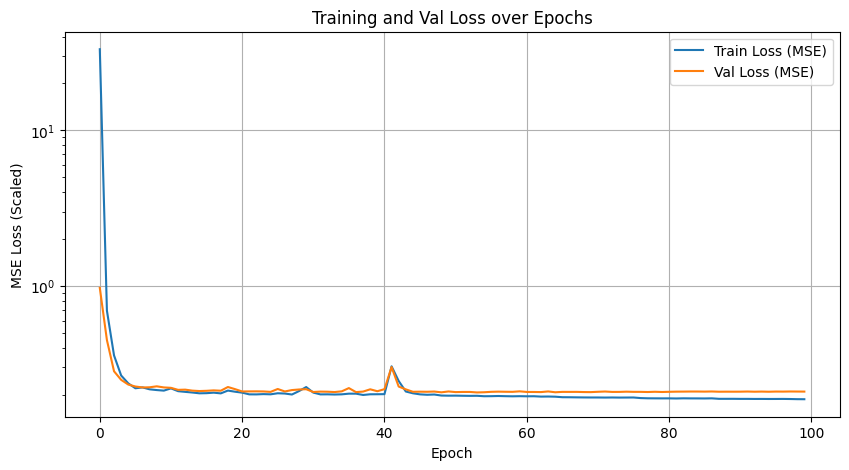

Model parameters successfully saved to 'mlp_model_weights.pth'
Data scalers successfully saved to 'scaler_X.pkl' and 'scaler_y.pkl'


In [10]:
# Cell for Training the MLP

# Hyperparameters
INPUT_DIM = X_train_raw.shape[1]
OUTPUT_DIM = y_train_raw.shape[1]

# Tunable Parameters (Increased Capacity)
HIDDEN_LAYERS = 5          # Typical 3
NEURONS_PER_LAYER = 512   # Typical 256
BATCH_SIZE = 256           # Typical 128
EPOCHS = 100               # Typical 100
REG_RATIO = 2.299341e-04        # Typical 1E-3
LEARNING_RATE = 5.520683e-03    # Typical 1E-3

# Record start time
start_time = time.time()

print("Starting One-Shot Training...")

# Create a single validation split (80% train, 20% validation) from the training tensor
indices = torch.randperm(X_train_tensor.size(0))
split = int(0.8 * X_train_tensor.size(0))
train_ids, val_ids = indices[:split], indices[split:]

X_train_single = X_train_tensor[train_ids]
y_train_single = y_train_tensor[train_ids]
X_val_single = X_train_tensor[val_ids]
y_val_single = y_train_tensor[val_ids]

# Initialize Model
model = TunableMLP(INPUT_DIM, OUTPUT_DIM, hidden_layers=HIDDEN_LAYERS, neurons_per_layer=NEURONS_PER_LAYER).to(device)

# Train
train_loss_hist, val_loss_hist = train_mlp(
    model,
    X_train_single, y_train_single,
    X_val_single, y_val_single,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    reg_ratio=REG_RATIO
)

# Record end time and print duration
end_time = time.time()
training_duration = end_time - start_time
print(f"\nTraining completed in: {training_duration:.2f} seconds")
print(f"Final Validation Loss: {val_loss_hist[-1]:.6f}")

# Plot Training Curves
plt.figure(figsize=(10, 5))
plt.plot(train_loss_hist, label='Train Loss (MAPE)')
plt.plot(val_loss_hist, label='Val Loss (MAPE)')
plt.xlabel('Epoch')
plt.ylabel('MAPE Loss (Scaled)')
plt.yscale('log') # Log scale to see small improvements
plt.title('Training and Val Loss over Epochs')
plt.legend()
plt.grid(True)
plt.show()

# 1. Save the PyTorch model's learned parameters
model_save_path = 'mlp_model_weights.pth'
torch.save(model.state_dict(), model_save_path)
print(f"Model parameters successfully saved to '{model_save_path}'")

# 2. Save the data scalers
scaler_x_path = 'scaler_X.pkl'
scaler_y_path = 'scaler_y.pkl'

joblib.dump(scaler_X, scaler_x_path)
joblib.dump(scaler_y, scaler_y_path)
print(f"Data scalers successfully saved to '{scaler_x_path}' and '{scaler_y_path}'")

<font color="blue"> **Step 7:** Find average MAPE for training and test data

In [8]:
print("Calculating MAPE on the full Training and Test datasets for individual components...")

model.eval()
with torch.no_grad():
    # ---- Training Set Evaluation ----
    # Get predictions for the full training set
    train_preds_scaled = model(X_train_tensor).cpu().numpy()
    # Inverse transform to get physical units
    train_preds_raw = 10 ** scaler_y.inverse_transform(train_preds_scaled)
    # Get original raw targets
    train_target_raw = 10 ** y_train_raw

    # Calculate overall and individual MAPE
    train_mape_overall = np.mean(np.abs((train_target_raw - train_preds_raw) / train_target_raw)) * 100
    train_mape_individual = np.mean(np.abs((train_target_raw - train_preds_raw) / train_target_raw), axis=0) * 100

    # ---- Test Set Evaluation ----
    # Get predictions for the full test set
    test_preds_scaled = model(X_test_tensor).cpu().numpy()
    # Inverse transform to get physical units
    test_preds_raw = 10 ** scaler_y.inverse_transform(test_preds_scaled)
    # Get original raw targets
    test_target_raw = 10 ** y_test_raw

    # Calculate overall and individual MAPE
    test_mape_overall = np.mean(np.abs((test_target_raw - test_preds_raw) / test_target_raw)) * 100
    test_mape_individual = np.mean(np.abs((test_target_raw - test_preds_raw) / test_target_raw), axis=0) * 100

print(f"\n=== Overall MAPE ===")
print(f"Average Training Set MAPE (Component Values): {train_mape_overall:.4f}%")
print(f"Average Test Set MAPE (Component Values): {test_mape_overall:.4f}%")

print(f"\n=== Individual Component MAPE ===")
# Create a DataFrame for nice formatting
mape_df = pd.DataFrame({
    'Component': output_cols,
    'Train MAPE (%)': train_mape_individual,
    'Test MAPE (%)': test_mape_individual
})
display(mape_df)


Calculating MAPE on the full Training and Test datasets for individual components...

=== Overall MAPE ===
Average Training Set MAPE (Component Values): 8.5727%
Average Test Set MAPE (Component Values): 8.9300%

=== Individual Component MAPE ===


,Component,Train MAPE (%),Test MAPE (%)
0,L_0,0.361712,0.414147
1,L_1,0.030059,0.031772
2,L_2,0.371746,0.405734
3,Cs_0,33.822899,33.045464
4,Cs_1,0.031712,0.032686
5,Cs_2,33.392941,33.873947
6,Cp_0,1.255443,1.288161
7,Cp_1,6.623782,10.018766
8,Cp_2,1.263979,1.259364


<font color="blue"> **Step 8a:** Hyperparameter tuning (optional)

In [9]:
# 1. Prepare a separate Validation set specifically for Optuna tuning
# (We split 20% from the training data to leave the final test set completely unseen)
X_opt_train, X_opt_val, y_opt_train, y_opt_val = train_test_split(
    X_train_tensor.cpu().numpy(), y_train_tensor.cpu().numpy(), test_size=0.2, random_state=42
)

# Convert back to tensors
X_opt_train_t = torch.tensor(X_opt_train).to(device)
y_opt_train_t = torch.tensor(y_opt_train).to(device)
X_opt_val_t = torch.tensor(X_opt_val).to(device)
y_opt_val_t = torch.tensor(y_opt_val).to(device)

# 2. Define the Objective Function for Optuna
def objective(trial):
    # Define the Search Space
    hidden_layers = trial.suggest_int('hidden_layers', 2, 6)
    neurons_per_layer = trial.suggest_categorical('neurons_per_layer', [64, 128, 256, 512])
    learning_rate = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
    reg_ratio = trial.suggest_float('reg_ratio', 1e-6, 1e-3, log=True)
    batch_size = trial.suggest_categorical('batch_size', [64, 128, 256])

    # Initialize the Model
    model = TunableMLP(
        input_dim=INPUT_DIM,
        output_dim=OUTPUT_DIM,
        hidden_layers=hidden_layers,
        neurons_per_layer=neurons_per_layer
    ).to(device)

    # Train the Model
    # Note: We use a smaller number of epochs (e.g., 40) during tuning to save time.
    train_loss_hist, val_loss_hist = train_mlp(
        model,
        X_opt_train_t, y_opt_train_t,
        X_opt_val_t, y_opt_val_t,
        epochs=80,
        batch_size=batch_size,
        learning_rate=learning_rate,
        reg_ratio=reg_ratio
    )

    # The objective value to minimize is the final validation loss (MSE)
    return val_loss_hist[-1]

# 3. Create the Study and Optimize
print("Starting Optuna Hyperparameter Tuning...")
print("This may take a while depending on the number of trials.")

tune_start = time.time()
study = optuna.create_study(direction='minimize', study_name="MLP_Hyperparameter_Tuning")

# Set n_trials. 15 is used here for demonstration. Increase this (e.g., 50-100) for a thorough search.
study.optimize(objective, n_trials=15)
tune_duration = time.time() - tune_start

print(f"\nOptuna Tuning Completed in {tune_duration:.2f} seconds!")

# Tuning Report
best_trial = study.best_trial
first_trial = study.trials[0]

print("="*60)
print("🎯 OPTUNA HYPERPARAMETER TUNING REPORT 🎯")
print("="*60)

print(f"Total combinations (trials) examined: {len(study.trials)}")

print("\n⚙️ HYPERPARAMETER SEARCH SPACE USED:")
print("  - hidden_layers:     int [2 to 6]")
print("  - neurons_per_layer: categorical [64, 128, 256, 512]")
print("  - learning_rate:     float [1e-4 to 1e-2] (logarithmic scale)")
print("  - reg_ratio:         float [1e-6 to 1e-3] (logarithmic scale)")
print("  - batch_size:        categorical [64, 128, 256]")

print("\n📈 MSE PERFORMANCE OVERVIEW:")
print(f"  - Start MSE (Trial 0): {first_trial.value:.6f}")
print(f"  - Final Best MSE:      {best_trial.value:.6f}")

if first_trial.value > best_trial.value:
    improvement = ((first_trial.value - best_trial.value) / first_trial.value) * 100
    print(f"  - Relative Improvement: {improvement:.2f}%")
else:
    print("  - Note: The first random trial happened to be the best, or no improvement was found.")

print("\n🏆 FINAL VARIABLES FOR MLP TRAINING (BEST HYPERPARAMETERS):")
print("Update your 'Hyperparameters' section in the training cell with these values:")
for key, value in best_trial.params.items():
    # Format floats nicely
    if isinstance(value, float):
        print(f"  - {key.upper()}: {value:.6e}")
    else:
        print(f"  - {key.upper()}: {value}")

print("="*60)

[I 2026-04-26 20:10:01,602] A new study created in memory with name: MLP_Hyperparameter_Tuning


Starting Optuna Hyperparameter Tuning...
This may take a while depending on the number of trials.
Starting training: Epochs=80, Batch=256, LR=0.00012941123555217093, Reg=2.253432121524e-06
Epoch 1/80 | Train Loss (MSE): 2.631785 | Test Loss (MSE): 1.269764 | LR: 0.000129
Epoch 10/80 | Train Loss (MSE): 0.333913 | Test Loss (MSE): 0.363398 | LR: 0.000129
Epoch 20/80 | Train Loss (MSE): 0.270545 | Test Loss (MSE): 0.313231 | LR: 0.000129
Epoch 30/80 | Train Loss (MSE): 0.240255 | Test Loss (MSE): 0.281689 | LR: 0.000129
Epoch 40/80 | Train Loss (MSE): 0.222012 | Test Loss (MSE): 0.264459 | LR: 0.000129
Epoch 50/80 | Train Loss (MSE): 0.207087 | Test Loss (MSE): 0.254935 | LR: 0.000129
Epoch 60/80 | Train Loss (MSE): 0.201364 | Test Loss (MSE): 0.250128 | LR: 0.000129
Epoch 70/80 | Train Loss (MSE): 0.197662 | Test Loss (MSE): 0.248698 | LR: 0.000129


[I 2026-04-26 20:10:08,232] Trial 0 finished with value: 0.24561867117881775 and parameters: {'hidden_layers': 2, 'neurons_per_layer': 256, 'learning_rate': 0.00012941123555217093, 'reg_ratio': 2.253432121524e-06, 'batch_size': 256}. Best is trial 0 with value: 0.24561867117881775.


Epoch 80/80 | Train Loss (MSE): 0.193355 | Test Loss (MSE): 0.245619 | LR: 0.000129
Starting training: Epochs=80, Batch=128, LR=0.00015500384617011953, Reg=8.40106717767239e-06
Epoch 1/80 | Train Loss (MSE): 0.917873 | Test Loss (MSE): 0.824171 | LR: 0.000155
Epoch 10/80 | Train Loss (MSE): 0.216515 | Test Loss (MSE): 0.239891 | LR: 0.000155
Epoch 20/80 | Train Loss (MSE): 0.199408 | Test Loss (MSE): 0.232974 | LR: 0.000155
Epoch 30/80 | Train Loss (MSE): 0.193266 | Test Loss (MSE): 0.226620 | LR: 0.000155
Epoch 40/80 | Train Loss (MSE): 0.190599 | Test Loss (MSE): 0.226901 | LR: 0.000155
Epoch 50/80 | Train Loss (MSE): 0.185388 | Test Loss (MSE): 0.227175 | LR: 0.000078
Epoch 60/80 | Train Loss (MSE): 0.182598 | Test Loss (MSE): 0.225991 | LR: 0.000039
Epoch 70/80 | Train Loss (MSE): 0.181144 | Test Loss (MSE): 0.226364 | LR: 0.000019


[I 2026-04-26 20:10:18,115] Trial 1 finished with value: 0.22627514600753784 and parameters: {'hidden_layers': 4, 'neurons_per_layer': 128, 'learning_rate': 0.00015500384617011953, 'reg_ratio': 8.40106717767239e-06, 'batch_size': 128}. Best is trial 1 with value: 0.22627514600753784.


...

Epoch 80/80 | Train Loss (MSE): 0.191638 | Test Loss (MSE): 0.221462 | LR: 0.000774
Starting training: Epochs=80, Batch=256, LR=0.0026338797723715374, Reg=1.3528465671490077e-05
Epoch 1/80 | Train Loss (MSE): 9.579983 | Test Loss (MSE): 0.724072 | LR: 0.002634
Epoch 10/80 | Train Loss (MSE): 0.202264 | Test Loss (MSE): 0.225026 | LR: 0.002634
Epoch 20/80 | Train Loss (MSE): 0.198864 | Test Loss (MSE): 0.222439 | LR: 0.002634
Epoch 30/80 | Train Loss (MSE): 0.196341 | Test Loss (MSE): 0.224333 | LR: 0.002634
Epoch 40/80 | Train Loss (MSE): 0.189136 | Test Loss (MSE): 0.223084 | LR: 0.001317
Epoch 50/80 | Train Loss (MSE): 0.185829 | Test Loss (MSE): 0.222606 | LR: 0.000658
Epoch 60/80 | Train Loss (MSE): 0.183734 | Test Loss (MSE): 0.225558 | LR: 0.000329
Epoch 70/80 | Train Loss (MSE): 0.181452 | Test Loss (MSE): 0.225110 | LR: 0.000329


[I 2026-04-26 20:13:11,968] Trial 13 finished with value: 0.22530820965766907 and parameters: {'hidden_layers': 3, 'neurons_per_layer': 512, 'learning_rate': 0.0026338797723715374, 'reg_ratio': 1.3528465671490077e-05, 'batch_size': 256}. Best is trial 12 with value: 0.2214619517326355.


Epoch 80/80 | Train Loss (MSE): 0.179933 | Test Loss (MSE): 0.225308 | LR: 0.000165
Starting training: Epochs=80, Batch=256, LR=0.002788937580731287, Reg=4.731300060994771e-05
Epoch 1/80 | Train Loss (MSE): 11.080458 | Test Loss (MSE): 0.797265 | LR: 0.002789
Epoch 10/80 | Train Loss (MSE): 0.203962 | Test Loss (MSE): 0.232181 | LR: 0.002789
Epoch 20/80 | Train Loss (MSE): 0.200897 | Test Loss (MSE): 0.225496 | LR: 0.002789
Epoch 30/80 | Train Loss (MSE): 0.197247 | Test Loss (MSE): 0.228330 | LR: 0.002789
Epoch 40/80 | Train Loss (MSE): 0.191205 | Test Loss (MSE): 0.225934 | LR: 0.001394
Epoch 50/80 | Train Loss (MSE): 0.187975 | Test Loss (MSE): 0.223296 | LR: 0.000697
Epoch 60/80 | Train Loss (MSE): 0.185691 | Test Loss (MSE): 0.223024 | LR: 0.000349
Epoch 70/80 | Train Loss (MSE): 0.184525 | Test Loss (MSE): 0.223651 | LR: 0.000174


[I 2026-04-26 20:13:27,177] Trial 14 finished with value: 0.22421662509441376 and parameters: {'hidden_layers': 3, 'neurons_per_layer': 512, 'learning_rate': 0.002788937580731287, 'reg_ratio': 4.731300060994771e-05, 'batch_size': 256}. Best is trial 12 with value: 0.2214619517326355.


Epoch 80/80 | Train Loss (MSE): 0.183879 | Test Loss (MSE): 0.224217 | LR: 0.000087

Optuna Tuning Completed in 205.58 seconds!
🎯 OPTUNA HYPERPARAMETER TUNING REPORT 🎯
Total combinations (trials) examined: 15

⚙️ HYPERPARAMETER SEARCH SPACE USED:
  - hidden_layers:     int [2 to 6]
  - neurons_per_layer: categorical [64, 128, 256, 512]
  - learning_rate:     float [1e-4 to 1e-2] (logarithmic scale)
  - reg_ratio:         float [1e-6 to 1e-3] (logarithmic scale)
  - batch_size:        categorical [64, 128, 256]

📈 MSE PERFORMANCE OVERVIEW:
  - Start MSE (Trial 0): 0.245619
  - Final Best MSE:      0.221462
  - Relative Improvement: 9.84%

🏆 FINAL VARIABLES FOR MLP TRAINING (BEST HYPERPARAMETERS):
Update your 'Hyperparameters' section in the training cell with these values:
  - HIDDEN_LAYERS: 2
  - NEURONS_PER_LAYER: 512
  - LEARNING_RATE: 3.096135e-03
  - REG_RATIO: 2.006500e-05
  - BATCH_SIZE: 256


<font color="blue"> **Step 8b:** Visualization of hyperparameter tuning (optional)

In [12]:
# Cell for Optuna Visualizations

print("Generating Interactive Optuna Visualizations...")

# 1. Optimization History: Shows how the validation MSE improved over trials
fig1 = vis.plot_optimization_history(study)
fig1.show()

# 2. Parameter Importances: Shows which hyperparameter had the biggest impact on MSE
fig2 = vis.plot_param_importances(study)
fig2.show()

# 3. Parallel Coordinate Plot: Shows the relationships and combinations of high-performing parameters
fig3 = vis.plot_parallel_coordinate(study)
fig3.show()

# 4. Slice Plot: Shows the distribution of each parameter against the objective value
fig4 = vis.plot_slice(study)
fig4.show()

Generating Interactive Optuna Visualizations...


<font color="blue"> **Step 9a:** Evaluation of MLP on new data that it has not seen during training

In [14]:
# Upload the saved paramters of MLP and filter response target

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Define paths (must match the saving cell)
model_save_path = '/content/drive/MyDrive/Data/mlp_model_weights.pth'
scaler_x_path = '/content/drive/MyDrive/Data/scaler_X.pkl'
scaler_y_path = '/content/drive/MyDrive/Data/scaler_y.pkl'

# 1. Load the scalers
loaded_scaler_X = joblib.load(scaler_x_path)
loaded_scaler_y = joblib.load(scaler_y_path)
print(f"Scalers successfully loaded from '{scaler_x_path}' and '{scaler_y_path}'")

# 2. Initialize the model structure
# We extract the input/output dimensions from the scalers
INPUT_DIM = loaded_scaler_X.n_features_in_
OUTPUT_DIM = loaded_scaler_y.n_features_in_
HIDDEN_LAYERS = 5
NEURONS_PER_LAYER = 512

model = TunableMLP(
    input_dim=INPUT_DIM,
    output_dim=OUTPUT_DIM,
    hidden_layers=HIDDEN_LAYERS,
    neurons_per_layer=NEURONS_PER_LAYER
).to(device)

# 3. Load the model weights
model.load_state_dict(torch.load(model_save_path, map_location=device, weights_only=True))

# 4. Set the model to evaluation mode
model.eval()
print(f"Model parameters successfully loaded from '{model_save_path}' and set to eval mode.")

# Define the path to the CSV file in your Google Drive
file_path = '/content/drive/MyDrive/Data/piecewise_filter_responses_small.csv'

# Load the CSV file into a pandas DataFrame
df_piecewise = pd.read_csv(file_path)

# Display the first few rows of the DataFrame to verify it loaded correctly
display(df_piecewise.head())
len(df_piecewise)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Scalers successfully loaded from '/content/drive/MyDrive/Data/scaler_X.pkl' and '/content/drive/MyDrive/Data/scaler_y.pkl'
Model parameters successfully loaded from '/content/drive/MyDrive/Data/mlp_model_weights.pth' and set to eval mode.


,FreqVec_MHz,H(f) 1,H(f) 2,H(f) 3,H(f) 4,H(f) 5,H(f) 6,H(f) 7,H(f) 8,H(f) 9,...,H(f) 991,H(f) 992,H(f) 993,H(f) 994,H(f) 995,H(f) 996,H(f) 997,H(f) 998,H(f) 999,H(f) 1000
0,1800.0000,-40.0,-54.167364,-46.469807,-50.54093,-40.0,-40.0,-47.247992,-40.0,-40.0,...,-48.918256,-40.0,-40.0,-56.427772,-42.251664,-58.71109,-40.0,-40.0,-40.0,-61.781604
1,1807.8125,-40.0,-54.167364,-46.469807,-50.54093,-40.0,-40.0,-47.247992,-40.0,-40.0,...,-48.918256,-40.0,-40.0,-56.427772,-42.251664,-58.71109,-40.0,-40.0,-40.0,-61.781604
2,1815.6250,-40.0,-54.167364,-46.469807,-50.54093,-40.0,-40.0,-47.247992,-40.0,-40.0,...,-48.918256,-40.0,-40.0,-56.427772,-42.251664,-58.71109,-40.0,-40.0,-40.0,-61.781604
3,1823.4375,-40.0,-54.167364,-46.469807,-50.54093,-40.0,-40.0,-47.247992,-40.0,-40.0,...,-48.918256,-40.0,-40.0,-56.427772,-42.251664,-58.71109,-40.0,-40.0,-40.0,-61.781604
4,1831.2500,-40.0,-54.167364,-46.469807,-50.54093,-40.0,-40.0,-47.247992,-40.0,-40.0,...,-48.918256,-40.0,-40.0,-56.427772,-42.251664,-58.71109,-40.0,-40.0,-40.0,-61.781604


129

<font color="blue"> **Step 9b:** Evaluation of MLP on a sample it has seen during training.

Unsupported Ngspice version 41


Evaluating one sample of trained MLP...


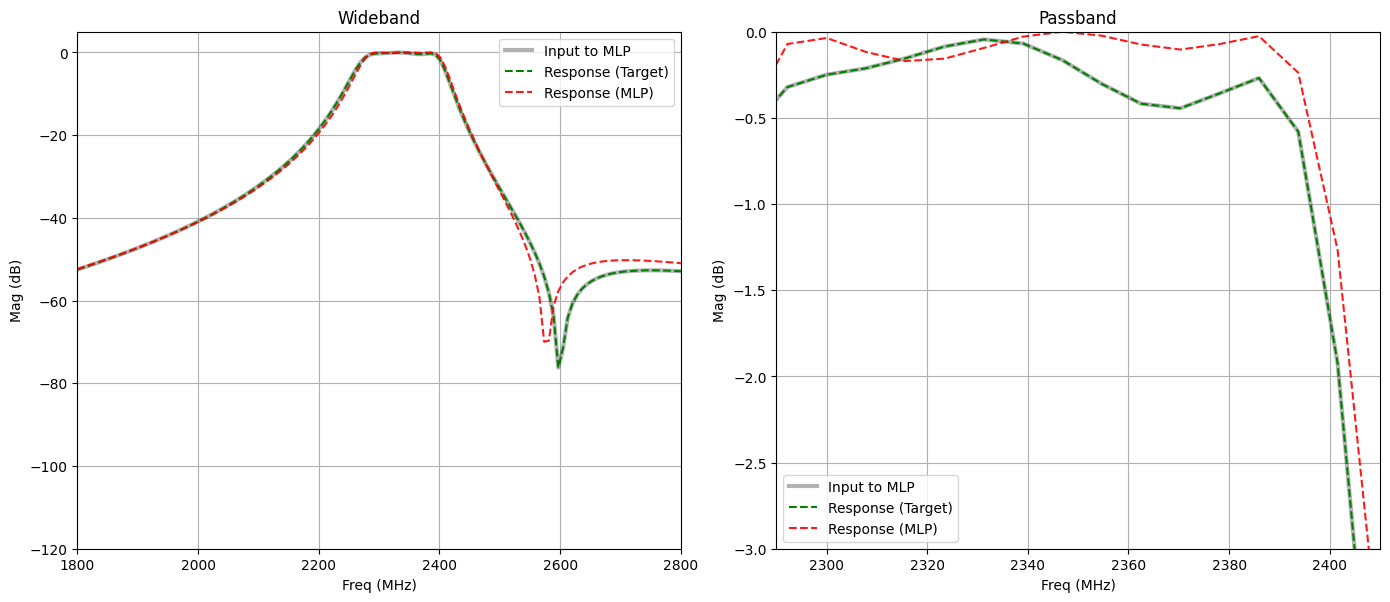

In [15]:
print("Evaluating one sample of trained MLP...")

# Select index from the test set
sample_idx = 149

input_sample_raw = X_test_raw[sample_idx]
target_sample_raw = 10 ** (y_test_raw[sample_idx])

# 1. Preprocess and Predict
input_sample_scaled = scaler_X.transform(input_sample_raw.reshape(1, -1))
model.eval()
with torch.no_grad():
    prediction_scaled = model(torch.tensor(input_sample_scaled).to(device))

prediction_raw = 10 ** scaler_y.inverse_transform(prediction_scaled.cpu().numpy()).flatten()

# Map predictions and targets to components
L_pred, Cs_pred, Cp_pred = np.zeros(3), np.zeros(3), np.zeros(3)
L_act, Cs_act, Cp_act = np.zeros(3), np.zeros(3), np.zeros(3)

for j, col in enumerate(output_cols):
    idx = int(col.split('_')[1])
    if 'L_' in col: L_pred[idx], L_act[idx] = prediction_raw[j], target_sample_raw[j]
    elif 'Cs_' in col: Cs_pred[idx], Cs_act[idx] = prediction_raw[j], target_sample_raw[j]
    elif 'Cp_' in col: Cp_pred[idx], Cp_act[idx] = prediction_raw[j], target_sample_raw[j]

# 2. Run AC Simulation
pred_mag_resp = ACsim(L_pred, Cs_pred, Cp_pred, FreqVec_MHz, render_mode=False)
act_mag_resp = ACsim(L_act, Cs_act, Cp_act, FreqVec_MHz, render_mode=False)

# 3. Calculate Error
mape_act = np.mean(np.abs((input_sample_raw - act_mag_resp) / (np.abs(input_sample_raw) + 1e-8))) * 100
mape_pred = np.mean(np.abs((input_sample_raw - pred_mag_resp) / (np.abs(input_sample_raw) + 1e-8))) * 100

# 4. Plotting
fig = plt.figure(figsize=(14, 8))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 3])

# ---- ROW 1, COL 0: Wideband Plot ----
ax_wide = fig.add_subplot(gs[1, 0])
ax_wide.plot(FreqVec_MHz, input_sample_raw, 'k', lw=3, alpha=0.3, label='Input to MLP')
ax_wide.plot(FreqVec_MHz, act_mag_resp, 'g--', lw=1.5, label='Response (Target)')
ax_wide.plot(FreqVec_MHz, pred_mag_resp, 'r--', lw=1.5, alpha=0.9, label='Response (MLP)')
ax_wide.set(title="Wideband", xlabel="Freq (MHz)", ylabel="Mag (dB)", xlim=(val_Freq_lo, val_Freq_hi), ylim=(-120, 5))
ax_wide.grid(True, which="both")
ax_wide.legend()

# ---- ROW 1, COL 1: Passband Plot ----
ax_pass = fig.add_subplot(gs[1, 1])
ax_pass.plot(FreqVec_MHz, input_sample_raw, 'k', lw=3, alpha=0.3, label='Input to MLP')
ax_pass.plot(FreqVec_MHz, act_mag_resp, 'g--', lw=1.5, label='Response (Target)')
ax_pass.plot(FreqVec_MHz, pred_mag_resp, 'r--', lw=1.5, alpha=0.9, label='Response (MLP)')
ax_pass.set(title="Passband", xlabel="Freq (MHz)", ylabel="Mag (dB)", xlim=(2290, 2410), ylim=(-3, 0))
ax_pass.grid(True, which="both")
ax_pass.legend()

plt.tight_layout()
plt.show()


<font color="blue"> **Step 9c:** Evaluation of MLP on new data that it has not seen during training. Optimize the MLP inference to see  how sub-optimal it is.

Starting post-inference optimization for a single profile...
Optimized H(f) 160 in 1.98s
Response Init MSE: 260.75 | Response Opt MSE: 254.91
Component MAPE (MLP vs Optimized): 8.54%


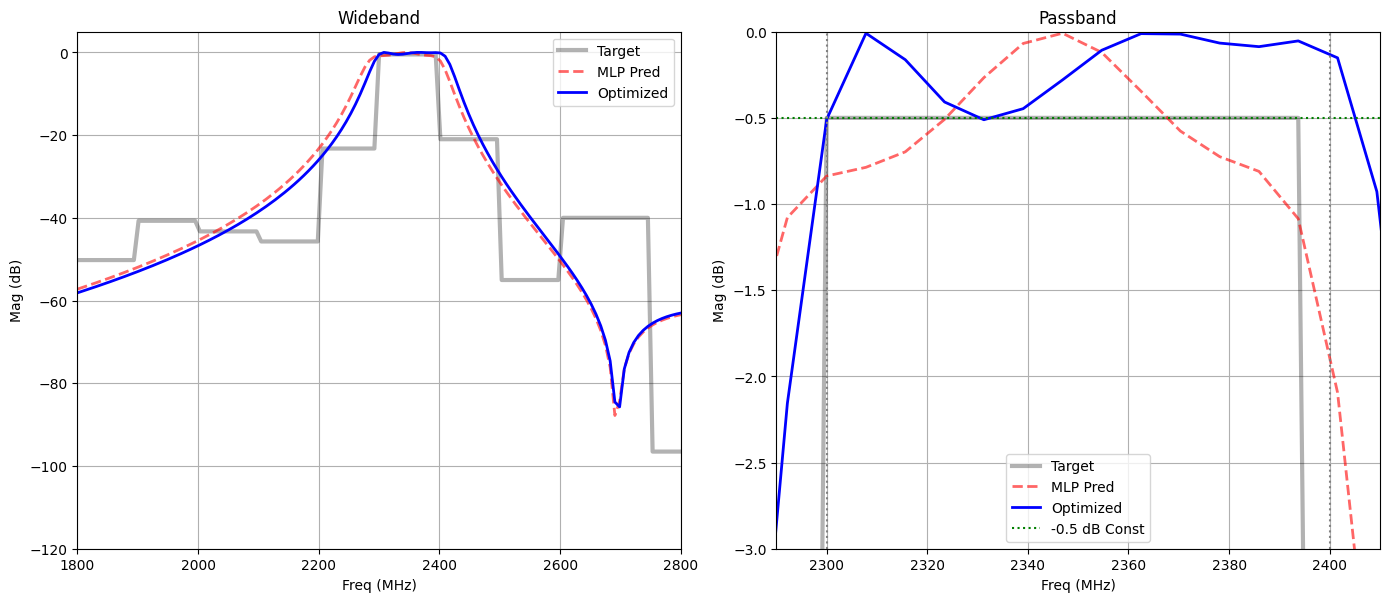

In [17]:
print("Starting post-inference optimization for a single profile...")

# Define a specific goal profile index to optimize
profile_index = 159
all_profile_cols = [c for c in df_piecewise.columns if c != 'FreqVec_MHz']
prof_name = all_profile_cols[profile_index]
input_sample_raw = df_piecewise[prof_name].values

# 1. Passband limits
pb_low, pb_high = 2300, 2400
passband_idx = np.where((FreqVec_MHz >= pb_low) & (FreqVec_MHz <= pb_high))[0]

# 2. MLP Prediction (Initial Guess)
input_scaled = scaler_X.transform(input_sample_raw.reshape(1, -1))
model.eval()
with torch.no_grad():
    pred_scaled = model(torch.tensor(input_scaled, dtype=torch.float32).to(device))

pred_raw = 10 ** scaler_y.inverse_transform(pred_scaled.cpu().numpy()).flatten()

# Map predictions to components
L_pred, Cs_pred, Cp_pred = np.zeros(3), np.zeros(3), np.zeros(3)
for j, col in enumerate(output_cols):
    idx = int(col.split('_')[1])
    if 'L_' in col: L_pred[idx] = pred_raw[j]
    elif 'Cs_' in col: Cs_pred[idx] = pred_raw[j]
    elif 'Cp_' in col: Cp_pred[idx] = pred_raw[j]

pred_mag_resp = ACsim(L_pred, Cs_pred, Cp_pred, FreqVec_MHz, render_mode=False)

# 3. Define Objective Function & Optimize
def optimize_filter(params):
    params = np.abs(params) # Prevent negative components
    mag = ACsim(params[0:3], params[3:6], params[6:9], FreqVec_MHz, render_mode=False)

    shape_error = np.mean((mag - input_sample_raw)**2)
    passband_penalty = np.sum(np.maximum(-0.5 - mag[passband_idx], 0)**2) * in_band_weight_Opt

    return shape_error + passband_penalty

start_time = time.time()
init_params = np.concatenate((L_pred, Cs_pred, Cp_pred))
res = minimize(optimize_filter, init_params, method='Nelder-Mead', options={'maxiter': 500})

# Extract optimized values
opt_params = np.abs(res.x)
L_opt, Cs_opt, Cp_opt = opt_params[0:3], opt_params[3:6], opt_params[6:9]
opt_mag_resp = ACsim(L_opt, Cs_opt, Cp_opt, FreqVec_MHz, render_mode=False)

# 4. Calculate MSE
def calc_mse(pred):
    return np.mean((input_sample_raw - pred)**2)

mse_resp_pred, mse_resp_opt = calc_mse(pred_mag_resp), calc_mse(opt_mag_resp)

# Calculate component MAPE between MLP guess and Optimized result
mape_comp = np.mean(np.abs((opt_params - init_params) / (np.abs(opt_params) + 1e-8))) * 100

print(f"Optimized {prof_name} in {time.time() - start_time:.2f}s")
print(f"Response Init MSE: {mse_resp_pred:.2f} | Response Opt MSE: {mse_resp_opt:.2f}")
print(f"Component MAPE (MLP vs Optimized): {mape_comp:.2f}%")

# 5. Plotting
fig = plt.figure(figsize=(14, 8))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 3])

# ---- ROW 1, COL 0: Wideband Plot ----
ax_wide = fig.add_subplot(gs[1, 0])
ax_wide.plot(FreqVec_MHz, input_sample_raw, 'k', lw=3, alpha=0.3, label='Target')
ax_wide.plot(FreqVec_MHz, pred_mag_resp, 'r--', lw=2, alpha=0.6, label='MLP Pred')
ax_wide.plot(FreqVec_MHz, opt_mag_resp, 'b-', lw=2, label='Optimized')
ax_wide.set(title="Wideband", xlabel="Freq (MHz)", ylabel="Mag (dB)", xlim=(val_Freq_lo, val_Freq_hi), ylim=(-120, 5))
ax_wide.grid(True, which="both")
ax_wide.legend()

# ---- ROW 1, COL 1: Passband Plot ----
ax_pass = fig.add_subplot(gs[1, 1])
ax_pass.plot(FreqVec_MHz, input_sample_raw, 'k', lw=3, alpha=0.3, label='Target')
ax_pass.plot(FreqVec_MHz, pred_mag_resp, 'r--', lw=2, alpha=0.6, label='MLP Pred')
ax_pass.plot(FreqVec_MHz, opt_mag_resp, 'b-', lw=2, label='Optimized')
ax_pass.axhline(-0.5, color='g', ls=':', label='-0.5 dB Const')
ax_pass.axvline(pb_low, color='gray', ls=':')
ax_pass.axvline(pb_high, color='gray', ls=':')
ax_pass.set(title="Passband", xlabel="Freq (MHz)", ylabel="Mag (dB)", xlim=(pb_low - 10, pb_high + 10), ylim=(-3, 0))
ax_pass.grid(True, which="both")
ax_pass.legend()

plt.tight_layout()
file_name = f'optimized_goals_comparison_{profile_index}.png'
plt.savefig(file_name, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


<font color="blue"> **Step 9d:** Comparing MLP inference with optimized design averaged over 100 cases  

In [15]:

print("Evaluating MLP performance and Optimization on 100 piecewise filter profiles...")
print("This may take a few minutes...")

# Passband limits based on profile index for optimization
pb_low, pb_high = 2300, 2400
passband_idx = np.where((FreqVec_MHz >= pb_low) & (FreqVec_MHz <= pb_high))[0]

# Get all profile columns except 'FreqVec_MHz'
all_profile_cols = [col for col in df_piecewise.columns if col != 'FreqVec_MHz']

# Randomly select 100 profiles
random.seed(42) # for reproducibility
selected_profile_cols = random.sample(all_profile_cols, 100)

all_mses_mlp = []
all_mses_opt = []

start_time = time.time()

for i, prof_name in enumerate(selected_profile_cols):
    input_sample_raw = df_piecewise[prof_name].values

    # ==========================================
    # 1. MLP Inference
    # ==========================================
    input_sample_scaled = scaler_X.transform(input_sample_raw.reshape(1, -1))

    model.eval()
    with torch.no_grad():
        input_tensor = torch.tensor(input_sample_scaled, dtype=torch.float32).to(device)
        prediction_scaled = model(input_tensor)
        prediction_scaled_np = prediction_scaled.cpu().numpy()

    # Inverse Transform to get physical units
    prediction_log = scaler_y.inverse_transform(prediction_scaled_np).flatten()
    prediction_raw = 10 ** prediction_log

    # Parse predicted values back into arrays for ACsim
    L_pred = np.zeros(3)
    Cs_pred = np.zeros(3)
    Cp_pred = np.zeros(3)

    for j, col_name in enumerate(output_cols):
        val_pred = prediction_raw[j]
        if col_name.startswith('L_'):
            L_pred[int(col_name.split('_')[1])] = val_pred
        elif col_name.startswith('Cs_'):
            Cs_pred[int(col_name.split('_')[1])] = val_pred
        elif col_name.startswith('Cp_'):
            Cp_pred[int(col_name.split('_')[1])] = val_pred

    # Run AC Simulation with MLP outputs
    pred_mag_resp = ACsim(L_pred, Cs_pred, Cp_pred, FreqVec_MHz, render_mode=False)

    # Calculate MSE for MLP Inference
    mse_pred = np.mean((input_sample_raw - pred_mag_resp)**2)
    all_mses_mlp.append(mse_pred)

    # ==========================================
    # 2. Fine-Tuned Optimization
    # ==========================================
    def optimize_filter(params):
        # Unpack parameters, use absolute value to prevent negative components
        params = np.abs(params)
        L_opt = params[0:3]
        Cs_opt = params[3:6]
        Cp_opt = params[6:9]

        # Simulate the circuit
        mag = ACsim(L_opt, Cs_opt, Cp_opt, FreqVec_MHz, render_mode=False)

        # Passband Constraint: Magnitude must be >= -0.5 dB
        passband_mag = mag[passband_idx]
        passband_penalty = np.sum(np.maximum(-0.5 - passband_mag, 0)**2) * in_band_weight_Opt

        # Overall Shape: Keep the rest of the response as close to the target as possible
        shape_error = np.mean((mag - input_sample_raw)**2)

        return shape_error + passband_penalty

    initial_params = np.concatenate((L_pred, Cs_pred, Cp_pred))
    res = minimize(optimize_filter, initial_params, method='Nelder-Mead', options={'maxiter': 500})

    # Extract and ensure positive values
    opt_params = np.abs(res.x)
    L_opt = opt_params[0:3]
    Cs_opt = opt_params[3:6]
    Cp_opt = opt_params[6:9]

    # Simulate optimal parameters
    opt_mag_resp = ACsim(L_opt, Cs_opt, Cp_opt, FreqVec_MHz, render_mode=False)

    # Calculate MSE for Optimized Result
    mse_opt = np.mean((input_sample_raw - opt_mag_resp)**2)
    all_mses_opt.append(mse_opt)

    if (i + 1) % 10 == 0:
        print(f"Processed {i + 1}/{len(selected_profile_cols)} profiles...")

# Calculate and report the average MSEs
total_time = time.time() - start_time
average_mse_mlp = np.mean(all_mses_mlp)
average_mse_opt = np.mean(all_mses_opt)

print(f"\nEvaluation Complete for {len(selected_profile_cols)} samples in {total_time:.2f} seconds.")
print(f"Average MSE (MLP Inference Only): {average_mse_mlp:.4f}")
print(f"Average MSE (Fine-Tuned Optimization): {average_mse_opt:.4f}")


Evaluating MLP performance and Optimization on 100 piecewise filter profiles...
This may take a few minutes...
Processed 10/100 profiles...
Processed 20/100 profiles...
Processed 30/100 profiles...
Processed 40/100 profiles...
Processed 50/100 profiles...
Processed 60/100 profiles...
Processed 70/100 profiles...
Processed 80/100 profiles...
Processed 90/100 profiles...
Processed 100/100 profiles...

Evaluation Complete for 100 samples in 193.00 seconds.
Average MSE (MLP Inference Only): 597.8374
Average MSE (Fine-Tuned Optimization): 532.6645
